####======================================================
### **Homework Assignment 4**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis). The dataset contains 310 data points (rows) and has 7 features (columns), including the label. The aim is to effectively classify/predict the patient class, using a binary classifier tree. The first tree with 2 predictors and the second tree with 6 predictors. To achieve this the sklearn, numpy, pandas, seaborn, and matplotlib packages were used. The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set, with X1 denoting the 2-predictor X matrix and X2 denoting the 2-predictor X matrix.

2. The 2-predictor binary tree was created and its decision boundaries in the 2-D space were displayed. Its confusion matrices, metrics, and prediction accuracies were calculated and displayed.

3. The 6-predictor binary tree was created. Its confusion matrices, metrics, and prediction accuracies were calculated and displayed.


#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [88]:
from distutils.version import LooseVersion

import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [89]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [90]:
# make X1 and X2 matrix
X1 = df.iloc[:, :2].rename(columns = {0: 'f0', 1: 'f1'})
X2 = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

In [91]:
X1

,f0,f1
0,63.03,22.55
1,39.06,10.06
2,68.83,22.22
3,69.30,24.65
4,49.71,9.65
...,...,...
305,47.90,13.62
306,53.94,20.72
307,61.45,22.69
308,45.25,8.69


In [92]:
X2

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [93]:
# make y vector and map the labels to integers
# 0 - disk hernia       - DH
# 1 - spondilolysthesis - SL
# 2 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 1, 'NO': 2}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,2
306,2
307,2
308,2


In [94]:
#split data into a training set (70%) and a testing set (30%)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size = 0.3, random_state = 1, stratify = y)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size = 0.3, random_state = 1, stratify = y)

In [95]:
#standardize features (training and testing dataset)
'''sc = StandardScaler()

sc.fit(X1_train)
X1_train = sc.transform(X1_train)
X1_test = sc.transform(X1_test)

sc.fit(X2_train)
X2_train = sc.transform(X2_train)
X2_test = sc.transform(X2_test)'''

'sc = StandardScaler()\n\nsc.fit(X1_train)\nX1_train = sc.transform(X1_train)\nX1_test = sc.transform(X1_test)\n\nsc.fit(X2_train)\nX2_train = sc.transform(X2_train)\nX2_test = sc.transform(X2_test)'

In [96]:
# transform the y vectors to be 1D arrays
y1_train = y1_train.values.ravel()
y1_test = y1_test.values.ravel()

y2_train = y2_train.values.ravel()
y2_test = y2_test.values.ravel()

#### ====================================================
#### FUNCTION TO PLOT DECISION REGIONS
#### ======================================================

In [97]:
# from chp3DecisionTree.ipynb

def plot_decision_regions(X, y, classifier, test_idx = None, resolution = 0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='Test set')

#### ====================================================
#### BUILD 2-PREDICTOR TREE CLASSIFIER
#### ======================================================

In [98]:
# class label names [disk hernia, spondylolisthesis, normal]

class_labels = ["DH", "SL", "NO"]

In [99]:
# create tree

tree1 = DecisionTreeClassifier(criterion = "gini", max_depth = 2, random_state = 2105)
tree1.fit(X1_train, y1_train)

y1_pred = tree1.predict(X1_test)

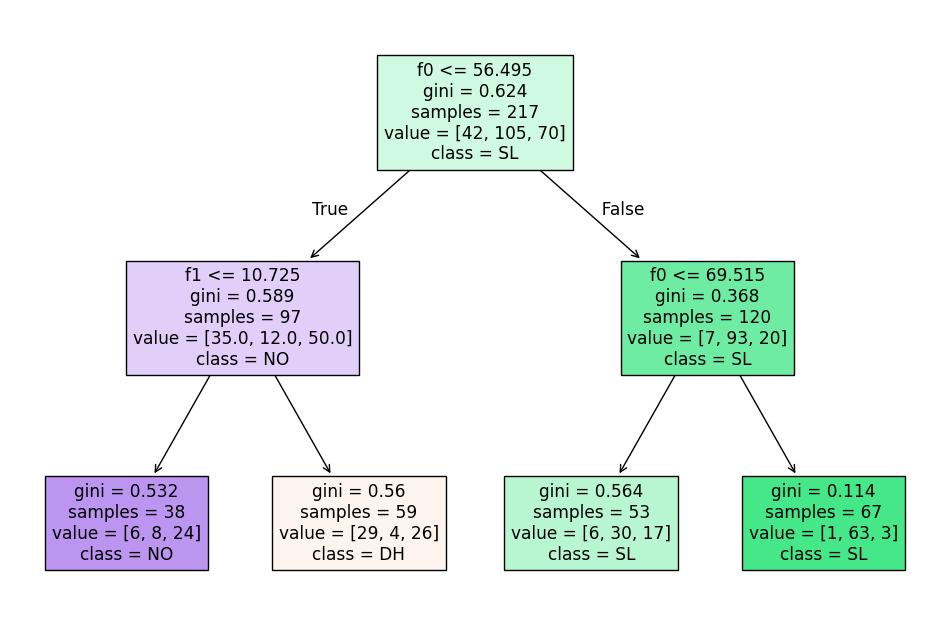

In [100]:
# plot tree

plt.figure(figsize = (12,8))
plot_tree(tree1, feature_names = X1.columns, class_names = class_labels, filled = True)
plt.show()

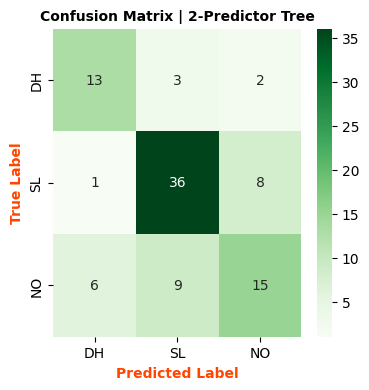

In [101]:
#create and plot confusion matrix

cm1 = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize = (4, 4))
sns.heatmap(cm1, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)
plt.title(f"Confusion Matrix | 2-Predictor Tree", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"Predicted Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"True Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

In [102]:
# output tree classifier's prediction accuracy

print(classification_report(y1_test, y1_pred, target_names = class_labels))
print(f"\n=====\n\nPrediction Accuracy: {accuracy_score(y1_test, y1_pred):.3f}")

              precision    recall  f1-score   support

          DH       0.65      0.72      0.68        18
          SL       0.75      0.80      0.77        45
          NO       0.60      0.50      0.55        30

    accuracy                           0.69        93
   macro avg       0.67      0.67      0.67        93
weighted avg       0.68      0.69      0.68        93


=====

Prediction Accuracy: 0.688


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


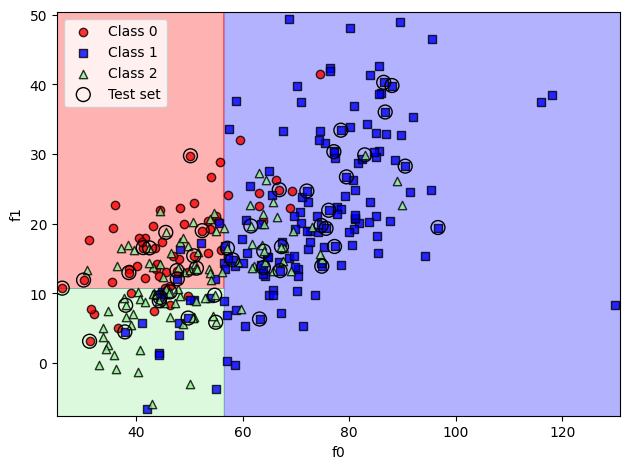

In [103]:
X1_combined = np.vstack((X1_train, X1_test))
y1_combined = np.hstack((y1_train, y1_test))

plot_decision_regions(X1_combined, y1_combined, classifier = tree1, test_idx = range(105, 150))
plt.xlabel('f0')
plt.ylabel('f1')
plt.legend(loc = 'upper left')
plt.tight_layout()
#plt.savefig('figures/03_06.png', dpi=300)
plt.show()

#### ====================================================
#### BUILD 6-PREDICTOR TREE CLASSIFIER
#### ======================================================

In [104]:
tree2 = DecisionTreeClassifier(criterion = "gini", max_depth = 5, random_state = 1303)
tree2.fit(X2_train, y2_train)

y2_pred = tree2.predict(X2_test)

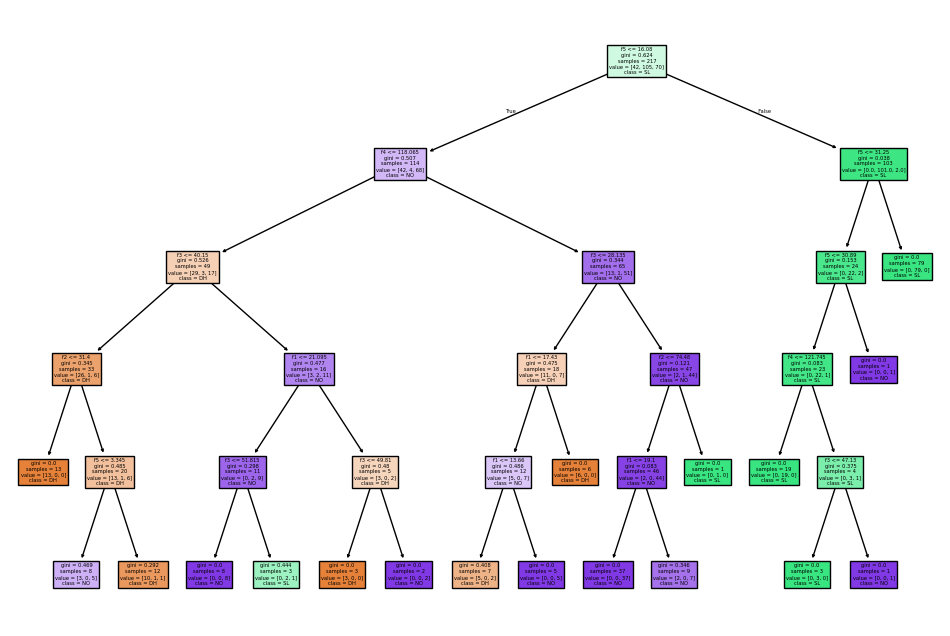

In [105]:
# plot tree

plt.figure(figsize = (12,8))
plot_tree(tree2, feature_names = X2.columns, class_names = class_labels, filled = True)
plt.show()

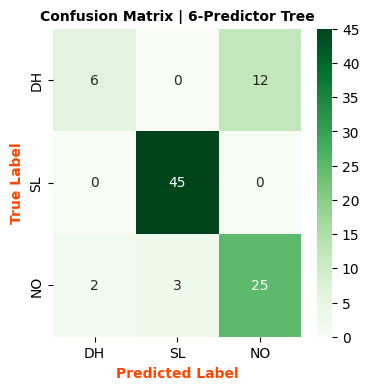

In [106]:
#create and plot confusion matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize = (4, 4))
sns.heatmap(cm2, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)
plt.title(f"Confusion Matrix | 6-Predictor Tree", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"Predicted Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"True Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

In [107]:
# output tree classifier's prediction accuracy

print(classification_report(y2_test, y2_pred, target_names = class_labels))
print(f"\n=====\n\nPrediction Accuracy: {accuracy_score(y2_test, y2_pred):.3f}")

              precision    recall  f1-score   support

          DH       0.75      0.33      0.46        18
          SL       0.94      1.00      0.97        45
          NO       0.68      0.83      0.75        30

    accuracy                           0.82        93
   macro avg       0.79      0.72      0.73        93
weighted avg       0.82      0.82      0.80        93


=====

Prediction Accuracy: 0.817


#### ====================================================
#### CONCLUSION + DISCUSSION
#### ======================================================

____________________________________________________________

**Tree Classifier:**

2-Predictor Tree Prediction Accuracy:

0.688

6-Predictor Tree Prediction Accuracy:

0.817

____________________________________________________________


By utilizing a higher dimensional space (going from the 2-predictor/2D tree to a 6-predictor/6D tree) the prediction accuracy of the tree was improved from 0.688 to 0.817. This is quite a noticeable improvement and points to the effectiveness of being able to partition regions using thresholds in a wider variety of dimensions that may contain unique information/spacing of data points that leads to easier grouping. The depth of the trees were not drastically different, and they are both relatively shallow, which means that they generally should not be overfitted to the test data.

